## SVR (Support Vector Regression) — `valor_aluguel ~ distancia_praia_km`

Mesma base e a mesma dupla `distancia_praia_km` → `valor_aluguel` dos notebooks
de regressão linear simples e polinomial — para comparar as formulações sobre
exatamente os mesmos dados. Em vez de escolher um grau de polinômio na mão, o
SVR encaixa um **tubo** de largura 2ε ao redor da função prevista e deixa o
kernel (`rbf`) achar a curva.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR

In [20]:
SEMENTE = 42
pd.set_option("display.width", 100)
df = pd.read_csv("aluguel_praia_polinomial.csv")

In [21]:

X = df[["distancia_praia_km"]].values
y = df["valor_aluguel"].values

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.30, random_state=SEMENTE
)
print(f"treino: {X_treino.shape[0]} imoveis   teste: {X_teste.shape[0]} imoveis")

treino: 700 imoveis   teste: 300 imoveis


### 1. O papel de epsilon e de C

- **epsilon (ε):** metade da largura do tubo. Pontos a menos de ε de distância
  da curva prevista não contam erro nenhum. Um ε maior tolera mais os dados como
  estão, então a curva final acompanha menos os detalhes finos.
- **C:** o quanto o modelo penaliza pontos que caem FORA do tubo. C alto
  persegue esses pontos de perto (risco de acompanhar ruído); C baixo aceita
  deixá-los mais longe do tubo.

### 2. Escolhendo epsilon e C com validação cruzada (`GridSearchCV`)

**Importante sobre metodologia:** os hiperparâmetros não podem ser escolhidos
olhando o desempenho no conjunto de **teste** — isso "vaza" informação do teste
para dentro do processo de treino e deixa a avaliação final otimista demais (o
modelo acaba escolhido porque "acertou" justamente os dados que deveriam medir
sua capacidade de generalizar). O jeito correto é usar **validação cruzada
dentro do treino**: `X_treino` é dividido em vários folds, cada combinação de
hiperparâmetros é treinada e avaliada várias vezes trocando qual fold vira
validação, e só a média dessas rodadas decide a combinação vencedora. O
`X_teste` só entra em cena depois, uma única vez, na Seção 3.

In [22]:
#grade_parametros = {
#    "epsilon": [50, 80, 120, 160, 200],
#    "C": [1000, 5000, 20000, 50000],
#}
grade_parametros = {
    "epsilon": [40, 80, 120, 200, 400],   # 5%, 10%, 15%, 25% e 50% do desvio-padrao do treino (~795,66)
    "C": [10, 100, 1000, 10000, 100000],  # escala logaritmica de verdade (ordem de grandeza em ordem de grandeza)
}

#Procura melhores valores para epsilon e C
busca = GridSearchCV(
    SVR(kernel="rbf", gamma="scale"),
    param_grid=grade_parametros,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
busca.fit(X_treino, y_treino)

print(f"melhores hiperparametros (por validacao cruzada no treino): {busca.best_params_}")
print(f"R^2 medio nos folds de validacao: {busca.best_score_:.4f}")

melhores hiperparametros (por validacao cruzada no treino): {'C': 100000, 'epsilon': 200}
R^2 medio nos folds de validacao: 0.7606


In [23]:
busca.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_C', 'param_epsilon', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

In [24]:
resultados_busca = pd.DataFrame(busca.cv_results_)[
    ["param_epsilon", "param_C", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)
resultados_busca.columns = ["epsilon", "C", "R2_medio_cv", "R2_desvio_cv"]
resultados_busca.round(4).head(10)

,epsilon,C,R2_medio_cv,R2_desvio_cv
23,200,100000,0.7606,0.0421
24,400,100000,0.7605,0.0376
17,120,10000,0.7601,0.0416
22,120,100000,0.7601,0.0430
15,40,10000,0.7596,0.0398
19,400,10000,0.7594,0.0365
20,40,100000,0.7592,0.0420
18,200,10000,0.7588,0.0406
21,80,100000,0.7581,0.0428
16,80,10000,0.7581,0.0416


**Leitura:** `R2_medio_cv` é a média do R² nos 5 folds de validação (só dentro
do treino) para cada combinação — é essa média, e não um número único de teste,
que decide qual combinação é "melhor". `R2_desvio_cv` mostra o quanto esse
resultado varia entre os folds; combinações com médias parecidas mas desvios
bem diferentes merecem um olhar a mais antes de escolher.

### 3. Avaliando a combinação vencedora no teste (uma única vez) e comparando com linear e polinomial

In [25]:
melhor_svr = busca.best_estimator_  # ja treinado com todo o X_treino, pelo GridSearchCV (refit=True por padrao)
pred_svr = melhor_svr.predict(X_teste)

poly2 = PolynomialFeatures(degree=2, include_bias=False)
Xtr_p2 = poly2.fit_transform(X_treino)
Xte_p2 = poly2.transform(X_teste)

modelo_poly2 = LinearRegression().fit(Xtr_p2, y_treino)
pred_poly2 = modelo_poly2.predict(Xte_p2)

modelo_linear = LinearRegression().fit(X_treino, y_treino)
pred_linear = modelo_linear.predict(X_teste)

comparacao = pd.DataFrame({
    "modelo": ["Linear simples (grau 1)", "Polinomial (grau 2)", f"SVR (rbf, {busca.best_params_})"],
    "R2_teste": [r2_score(y_teste, pred_linear), r2_score(y_teste, pred_poly2), r2_score(y_teste, pred_svr)],
    "MAE_teste": [mean_absolute_error(y_teste, pred_linear), mean_absolute_error(y_teste, pred_poly2), mean_absolute_error(y_teste, pred_svr)],
    "RMSE_teste": [mean_squared_error(y_teste, pred_linear) ** 0.5, mean_squared_error(y_teste, pred_poly2) ** 0.5, mean_squared_error(y_teste, pred_svr) ** 0.5],
})
comparacao.round(2)

,modelo,R2_teste,MAE_teste,RMSE_teste
0,Linear simples (grau 1),0.48,418.62,530.56
1,Polinomial (grau 2),0.68,324.97,415.79
2,"SVR (rbf, {'C': 100000, 'epsilon': 200})",0.71,321.03,399.59


**Leitura:** repare que o R² de teste do SVR pode ficar um pouco diferente do
`R2_medio_cv` da Seção 2 — são medidos em conjuntos diferentes (folds de
validação dentro do treino vs. o teste, visto uma única vez). Uma diferença
grande entre os dois é sinal de alerta; uma diferença pequena é o esperado e dá
mais confiança de que o resultado do teste não foi sorte.

### 4. Visualizando as curvas e o tubo do SVR

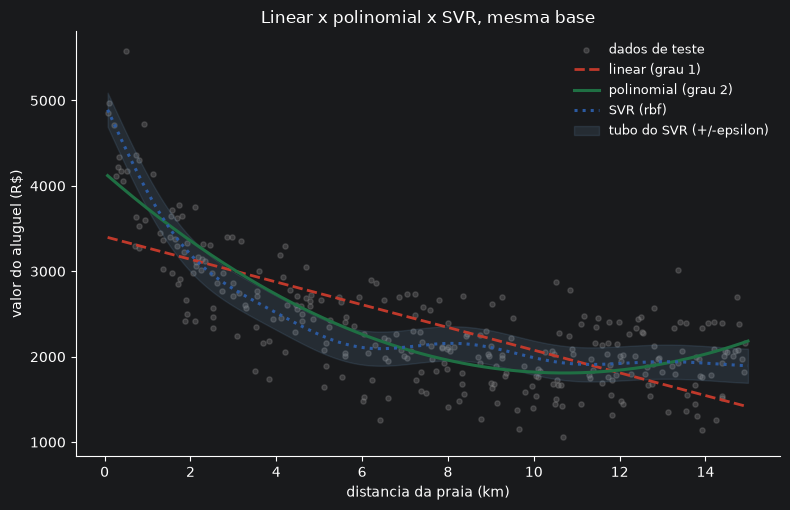

In [26]:
EPSILON_ESCOLHIDO = busca.best_params_["epsilon"]

grade = np.linspace(df["distancia_praia_km"].min(), df["distancia_praia_km"].max(), 300).reshape(-1, 1)

y_linear = modelo_linear.predict(grade)
y_poly2 = modelo_poly2.predict(poly2.transform(grade))
y_svr = melhor_svr.predict(grade)

fig, ax = plt.subplots(figsize=(8, 5.2))
ax.scatter(X_teste, y_teste, s=14, alpha=0.3, color="#8a8a8a", label="dados de teste")
ax.plot(grade, y_linear, color="#c0392b", linewidth=2, linestyle="--", label="linear (grau 1)")
ax.plot(grade, y_poly2, color="#1f6f43", linewidth=2.2, label="polinomial (grau 2)")
ax.plot(grade, y_svr, color="#2c5aa0", linewidth=2.2, linestyle=":", label="SVR (rbf)")
ax.fill_between(grade.ravel(), y_svr - EPSILON_ESCOLHIDO, y_svr + EPSILON_ESCOLHIDO, color="#7fb3e0", alpha=0.12, label="tubo do SVR (+/-epsilon)")

ax.set_xlabel("distancia da praia (km)")
ax.set_ylabel("valor do aluguel (R$)")
ax.set_title("Linear x polinomial x SVR, mesma base")
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

**Leitura:** a reta (grau 1) fica sistematicamente acima da curva real longe da
praia e abaixo perto dela; a polinomial e o SVR acompanham o decaimento de
forma parecida, cada um por um caminho diferente (transformar o atributo x
deixar o kernel achar a curva).

### 5. Pesquisar um valor

In [27]:
def prever_valor_aluguel(distancia_km):
    X_novo = np.array([[distancia_km]])
    return melhor_svr.predict(X_novo)[0]


try:
    entrada = input("Digite a distancia da praia em km: ")
    distancia_pesquisada = float(entrada.replace(",", "."))
except Exception:
    distancia_pesquisada = 3.0
    print(f"(entrada interativa indisponivel - usando valor de exemplo: {distancia_pesquisada} km)")

valor_previsto = prever_valor_aluguel(distancia_pesquisada)
print(f"\nDistancia pesquisada: {distancia_pesquisada:.2f} km")
print(f"Valor de aluguel previsto (SVR, {busca.best_params_}): R$ {valor_previsto:.2f}")


Distancia pesquisada: 5.00 km
Valor de aluguel previsto (SVR, {'C': 100000, 'epsilon': 200}): R$ 2258.88


### O que guardar deste notebook

- Hiperparâmetros (`epsilon`, `C`) foram escolhidos por validação cruzada
  **dentro do treino** (`GridSearchCV`) — o teste só apareceu depois, uma única
  vez, para a avaliação final. Ajustar hiperparâmetros olhando o resultado no
  teste é vazamento de dados e deixa a avaliação otimista demais.
- SVR troca a escolha manual do grau polinomial por dois hiperparâmetros
  (`epsilon`, `C`) e um kernel — o custo é justamente precisar dessa busca.
- Comparados lado a lado (Seção 3), linear, polinomial e SVR mostram o mesmo
  espectro: da formulação mais simples e mais limitada até as que acompanham a
  curva real — cada uma com seu próprio custo (interpretabilidade, número de
  hiperparâmetros, tempo de ajuste).